# KdV PINN

Notebook for studying and testing training

### Preamble

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from models import KdV_pinn
from train import train_pinn, pretrain
from sampling import sample_bulk
from physics import kdv, soliton_library
from configuration import kdv_config, config_to_dict, dict_to_config
from plot_utils import plot_field_visualization
from functools import partial


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

Using mps device.


### Load and modify configuration

In [2]:
training_config = kdv_config
training_config.num_epochs = 500
training_config.num_samp_bulk = 100
training_config.num_samp_eval = 128
training_config.plot_interval = 10
training_config.Lmax = 5
training_config.soliton_type = 'sech'
training_config.kappa = 1
training_config.lambda_BC = 0.1
training_config.lambda_kdv = 1
training_config.vmin = 0
training_config.vmax = 2
torch.manual_seed(training_config.seed)

### Load and train model
Plots updated interactively

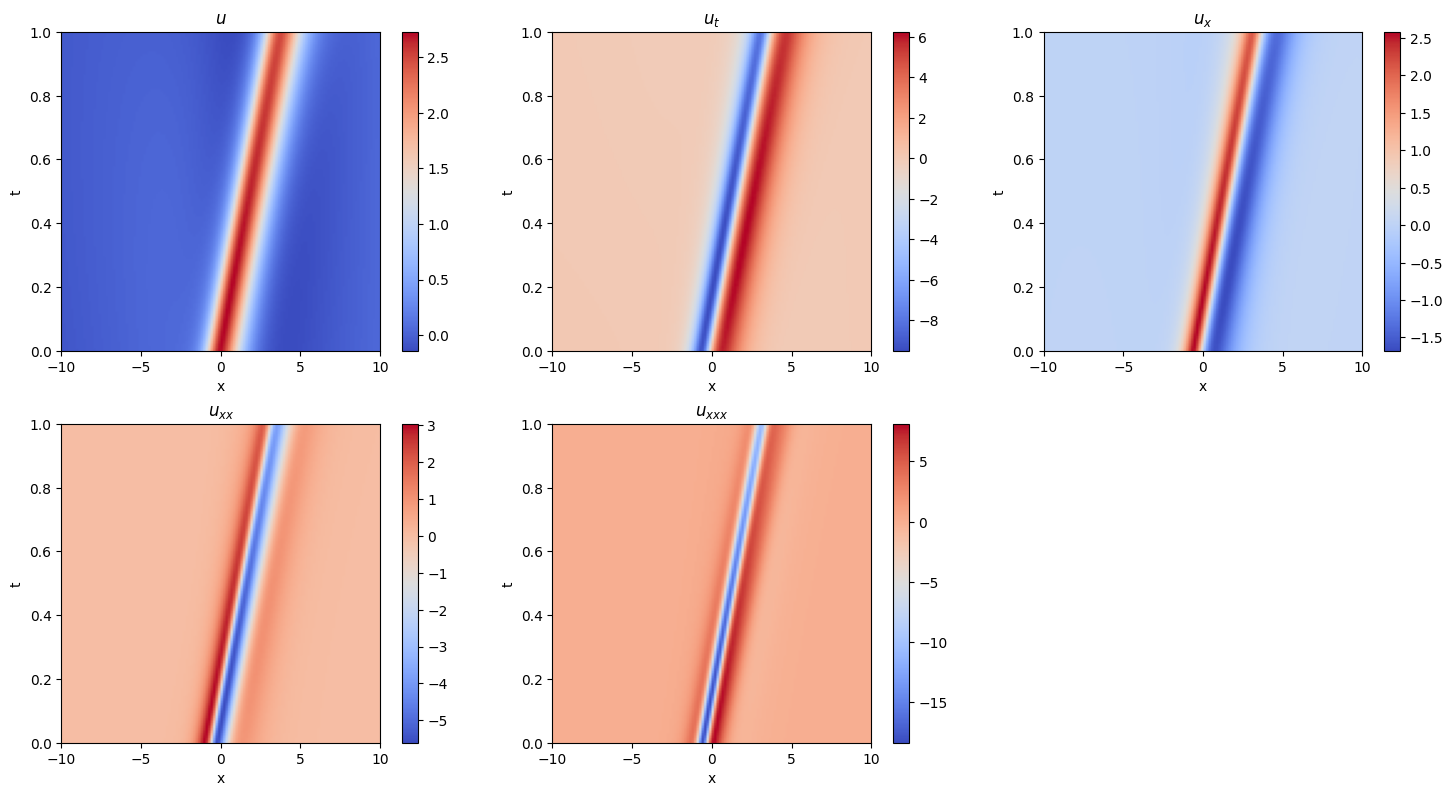

In [3]:
model = KdV_pinn(training_config).to(device)
fcn = partial(soliton_library['gauss'], config=training_config)
pretrain(model, fcn, training_config, device, num_epochs=200)
input_eval = sample_bulk(training_config, resample=False, num_samp=128).to(device)
input_eval.requires_grad_(True)
u0 = model(input_eval)
results0 = kdv(u0, input_eval)
plot_field_visualization(results0, training_config, 'deriv')

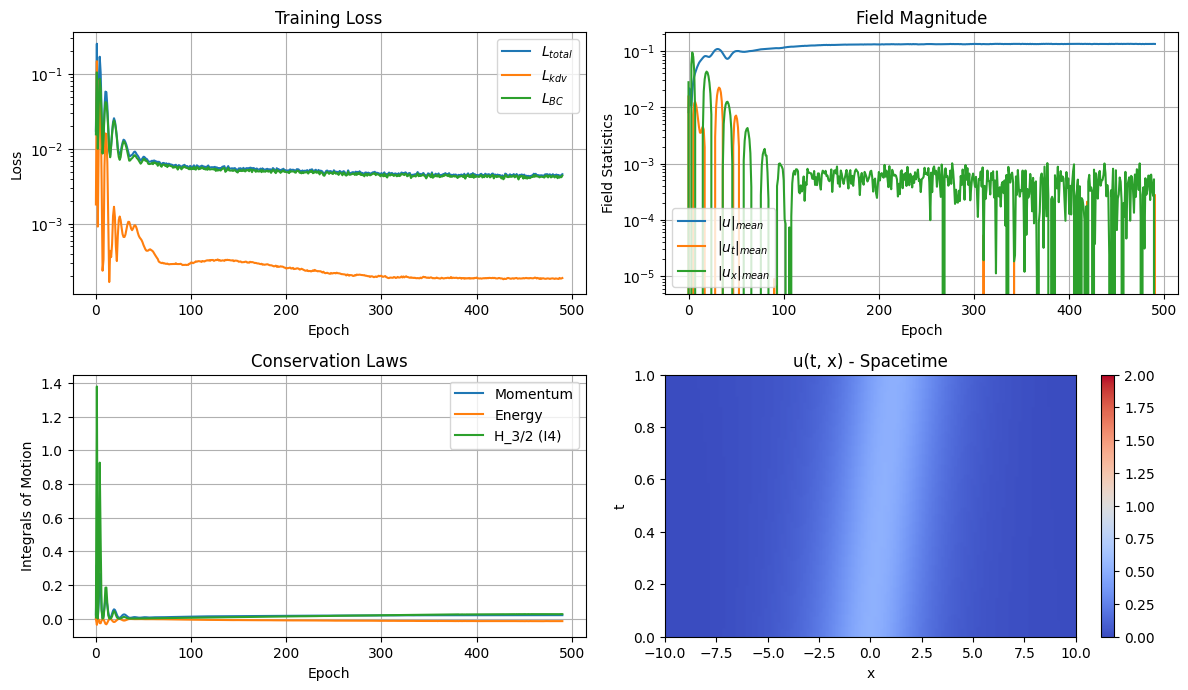

Training complete!


In [4]:
model = KdV_pinn(training_config).to(device)
result = train_pinn(model, training_config, device, interactive=True)
print("Training complete!")

### Save Model

In [5]:
torch.save({
    'model_state_dict': result['model'].state_dict(),
    'optimizer_state_dict': result['optimizer'].state_dict(),
    'config': config_to_dict(training_config),
    'metrics': result['metrics']
}, 'pinn_model.pt')
print("Model saved to pinn_model.pt")

Model saved to pinn_model.pt


### Load Model

In [6]:
checkpoint = torch.load('pinn_model.pt')
loaded_config = dict_to_config(checkpoint['config'])
loaded_model = KdV_pinn(loaded_config).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
print("Model loaded successfully!")

Model loaded successfully!


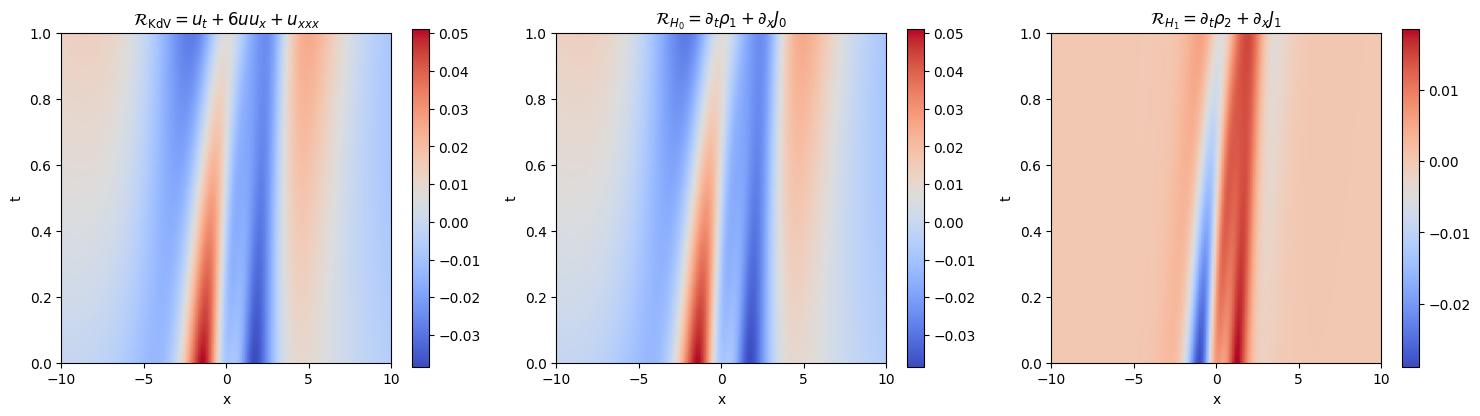

In [7]:
input_eval = sample_bulk(training_config, resample=False, num_samp=128).to(device)
input_eval.requires_grad_(True)
u = model(input_eval)
results = kdv(u, input_eval)
plot_field_visualization(results, training_config, 'res')

### Field Derivatives

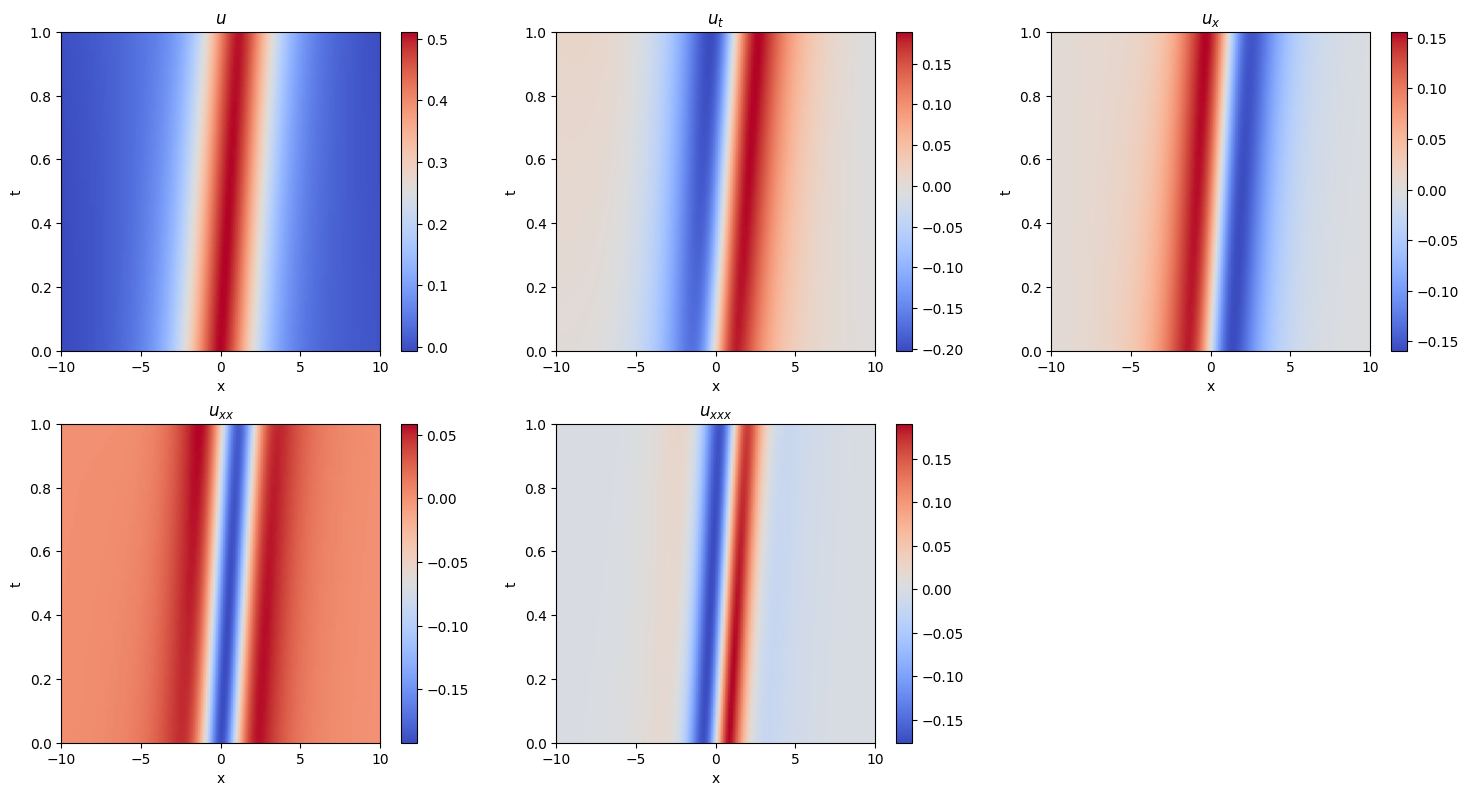

In [8]:
plot_field_visualization(results, training_config, 'deriv')

### Integrals of Motion

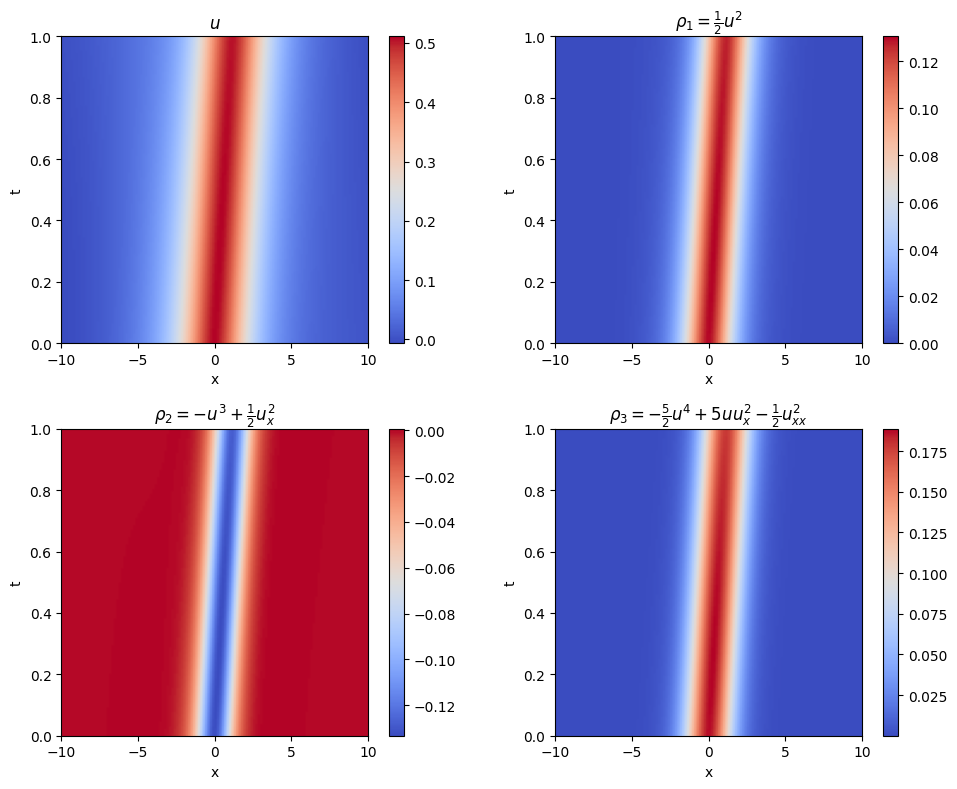

In [9]:
plot_field_visualization(results, training_config, 'iom')

### Conservation Currents

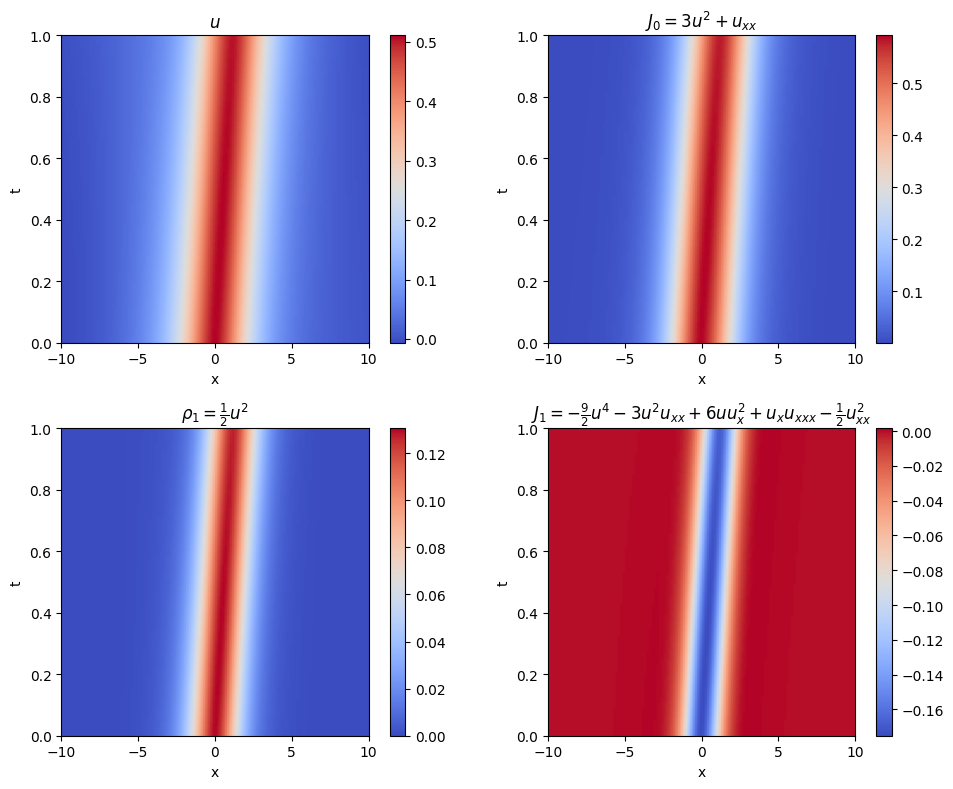

: 

In [ ]:
plot_field_visualization(results, training_config, 'curr')